<center><img src="car.jpg" width=500></center>


Insurance companies invest a lot of time and money into optimizing their pricing and accurately estimating the likelihood that customers will make a claim. In many countries, it is a legal requirement to have car insurance in order to drive a vehicle on public roads, so the market is very large!

[Source](https://www.accenture.com/_acnmedia/pdf-84/accenture-machine-leaning-insurance.pdf)

Knowing all of this, _On the Road car insurance_ have requested your services in building a model to predict whether a customer will make a claim on their insurance during the policy period. As they have very little expertise and infrastructure for deploying and monitoring machine learning models, they've asked you to identify the single feature that results in the best performing model, as measured by accuracy, so they can start with a simple model in production.

They have supplied you with their customer data as a csv file called `car_insurance.csv`, along with a table detailing the column names and descriptions below.

# The Dataset

| Column | Description |
|--------|-------------|
| `id` | Unique client identifier |
| `age` | Client's age: <br> <ul><li>`0`: 16-25</li><li>`1`: 26-39</li><li>`2`: 40-64</li><li>`3`: 65+</li></ul> |
| `gender` | Client's gender: <br> <ul><li>`0`: Female</li><li>`1`: Male</li></ul> |
| `driving_experience` | Years the client has been driving: <br> <ul><li>`0`: 0-9</li><li>`1`: 10-19</li><li>`2`: 20-29</li><li>`3`: 30+</li></ul> |
| `education` | Client's level of education: <br> <ul><li>`0`: No education</li><li>`1`: High school</li><li>`2`: University</li></ul> |
| `income` | Client's income level: <br> <ul><li>`0`: Poverty</li><li>`1`: Working class</li><li>`2`: Middle class</li><li>`3`: Upper class</li></ul> |
| `credit_score` | Client's credit score (between zero and one) |
| `vehicle_ownership` | Client's vehicle ownership status: <br><ul><li>`0`: Does not own their vehicle (paying off finance)</li><li>`1`: Owns their vehicle</li></ul> |
| `vehicle_year` | Year of vehicle registration: <br><ul><li>`0`: Before 2015</li><li>`1`: 2015 or later</li></ul> |
| `married` | Client's marital status: <br><ul><li>`0`: Not married</li><li>`1`: Married</li></ul> |
| `children` | Client's number of children |
| `postal_code` | Client's postal code | 
| `annual_mileage` | Number of miles driven by the client each year |
| `vehicle_type` | Type of car: <br> <ul><li>`0`: Sedan</li><li>`1`: Sports car</li></ul> |
| `speeding_violations` | Total number of speeding violations received by the client | 
| `duis` | Number of times the client has been caught driving under the influence of alcohol |
| `past_accidents` | Total number of previous accidents the client has been involved in |
| `outcome` | Whether the client made a claim on their car insurance (response variable): <br><ul><li>`0`: No claim</li><li>`1`: Made a claim</li></ul> |

In [190]:
#Import required modules
import pandas as pd
import numpy as np
from statsmodels.formula.api import logit

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

In [3]:
#import data
orig_data = pd.read_csv('car_insurance.csv')
display(orig_data.head(5))
display(orig_data.info())

,id,age,gender,driving_experience,education,income,credit_score,vehicle_ownership,vehicle_year,married,children,postal_code,annual_mileage,vehicle_type,speeding_violations,duis,past_accidents,outcome
0,569520,3,0,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,0,1,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,0,0,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,0,1,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,1,1,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   10000 non-null  int64  
 1   age                  10000 non-null  int64  
 2   gender               10000 non-null  int64  
 3   driving_experience   10000 non-null  object 
 4   education            10000 non-null  object 
 5   income               10000 non-null  object 
 6   credit_score         9018 non-null   float64
 7   vehicle_ownership    10000 non-null  float64
 8   vehicle_year         10000 non-null  object 
 9   married              10000 non-null  float64
 10  children             10000 non-null  float64
 11  postal_code          10000 non-null  int64  
 12  annual_mileage       9043 non-null   float64
 13  vehicle_type         10000 non-null  object 
 14  speeding_violations  10000 non-null  int64  
 15  duis                 10000 non-null  

None

## Inspecting, cleaning data
The original dataset has 10,000 rows & 18 columns. Only two columns, "credit_score" & "annual_mileage," have missing values; 982 & 957 respectively.

With respect to the column descriptions listed above, it appears that some columns comply with the specified numerical values for certain non-numerical values, but not all of them do (e.g. "education," "income"). Before performing the modeling process, these values should be converted to numerical values as specified above because models cannot be made using non-numeric data. Beforehand, the values of each column should be investigated to determine if any cleaning is necessary.

In [76]:
#inspect the values of each column
    #do this 1 by 1 because of how many columns there are

display(orig_data.columns)
display(orig_data['outcome'].value_counts(dropna=False).sort_values(ascending=False))
display(orig_data['outcome'].value_counts(dropna=False).sort_index())

Index(['id', 'age', 'gender', 'driving_experience', 'education', 'income',
       'credit_score', 'vehicle_ownership', 'vehicle_year', 'married',
       'children', 'postal_code', 'annual_mileage', 'vehicle_type',
       'speeding_violations', 'duis', 'past_accidents', 'outcome'],
      dtype='object')

outcome
0.0    6867
1.0    3133
Name: count, dtype: int64

outcome
0.0    6867
1.0    3133
Name: count, dtype: int64

Based on the inspection of the variables, those that do need/don't need cleaning are:
- **Need cleaning:** "driving_experience" (values), "education" (values), "income" (values), "credit_score" (nulls), "vehicle_ownership" (data type), "vehicle_year" (values), "married" (data type), "children" (data type), "annual_mileage" (data type, nulls), "vehicle_type" (values), "outcome" (data type)
- **Good:** "id", "age", "gender", "postal_code", "speeding_violiations", "duis", "past_accidents"

In [51]:
#Clean values of variables, except nulls
#make a new dataset for these modifications
data_I = orig_data.copy()

#"driving_experience"
data_I['driving_experience'] = data_I['driving_experience'].replace({'0-9y':0, '10-19y':1, '20-29y':2, '30y+':3})

#"education"
data_I['education'] = data_I['education'].replace({'none':0, 'high school':1, 'university':2})

#"income"
data_I['income'] = data_I['income'].replace({"poverty":0, "working class":1, "middle class":2, "upper class":3})

#"vehicle_ownership"
data_I['vehicle_ownership'] = data_I['vehicle_ownership'].astype('int')

#"vehicle_year"
data_I['vehicle_year'] = data_I['vehicle_year'].replace({'before 2015':0, 'after 2015':1})

#"married"
data_I['married'] = data_I['married'].astype('int')

#"children"
data_I['children'] = data_I['children'].astype('int')

#"vehicle_type"    0: Sedan, 1: Sports car
data_I['vehicle_type'] = data_I['vehicle_type'].replace({'sedan':0, 'sports car':1})

#"outcome"
data_I['outcome'] = data_I['outcome'].astype('int')


For the missing values in the "credit_score" & "annual_mileage" columns, since these variables contain numerical values, a convenient method would be to impute these missing values with some aggregate metric, like the mean or median. To determine which is more appropriate, examining their distributions can help. Usually, the median is the safest option.
- Use the **mean** when:
    - Data is normally distributed,
    - Data has skew ~ 0.
    - Essentially, where there are none/very few outliers that have a small influence.
- Use the **median** when:
    - Data is skewed,
    - Data has skew !~ 0.
    - Essentially, where there are multiple outliers that have a considerable influence.

C:\Users\elija\AppData\Local\Temp\ipykernel_12476\3816469240.py:26: UserWarning: The figure layout has changed to tight
  plt.tight_layout();


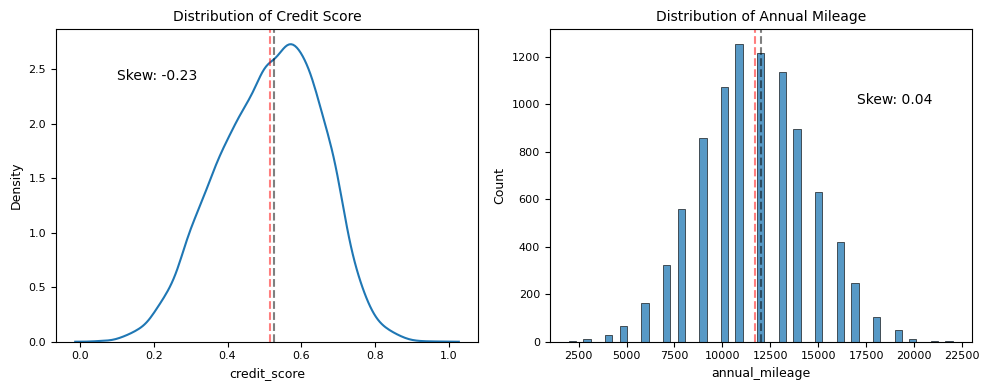

In [75]:
#Deal with missing values -- Examine distributions of "credit_score", "annual_mileage"

fig, axes = plt.subplots(ncols=2, figsize=(10,4))

#plot "credit_score", the mean (red), median (black), skew
ax1 = sns.kdeplot(data=orig_data, x='credit_score', ax=axes[0])
ax1.axvline(orig_data.credit_score.mean(), color='red', linestyle='--', alpha=0.5)
ax1.axvline(orig_data.credit_score.median(), color='black', linestyle='--', alpha=0.5)
ax1.text(0.1,2.4, "Skew: {}".format(round(orig_data.credit_score.skew(), 2)))

#plot "annual_mileage", the mean (red), median (black), skew
ax2 = sns.histplot(data=orig_data, x='annual_mileage', ax=axes[1])
ax2.axvline(orig_data.annual_mileage.mean(), color='red', linestyle='--', alpha=0.5)
ax2.axvline(orig_data.annual_mileage.median(), color='black', linestyle='--', alpha=0.5)
ax2.text(17000,1000, "Skew: {}".format(round(orig_data.annual_mileage.skew(), 2)))

#edit plot details
for key, v in {"Distribution of Credit Score":[0, 'credit_score', 'Density'], 
               "Distribution of Annual Mileage":[1, 'annual_mileage', 'Count']}.items():
    plt.sca(axes[v[0]])
    plt.title(key, fontsize=10)
    plt.xticks(fontsize=8)
    plt.xlabel(v[1], fontsize=9)
    plt.yticks(fontsize=8)
    plt.ylabel(v[2], fontsize=9)
    plt.tight_layout();

The two plots above display distributions for the "credit_score" & "annual_mileage" variables respectively. The "credit_score" plot is a kernel density estimate because it contained non-integer values, which a histogram is unable to plot. These plots were made to help determine whether the mean or median is more useful for imputing the missing values in these two variables.

For "credit_score," there is a slight negative (left) skew, & the mean & median are very similar. It has a skew coefficient of about -0.23. Recall that there are 982 missing values in this column (9.8%). Given the shape of the distribution & the fairly large skew coefficient, the median would be a better imputation metric for this variable. In the original dataset, "credit_score" values have six decimal values, & so the imputed median should also have six decimals.

For "annual_mileage," there is a slight positive (right) skew, & the mean & median are fairly similar given the range of annual mileages (about 20,000 miles). It has a skew coefficient of about 0.04. Recall that there are 957 missing values in this column (9.6%). The distribution of this histogram is closer to a bell-shaped normal curve than the "credit_score" plot was. Given this normal-esque shape & small skew coefficient, the mean is a good imputation metric for this variable. In the original dataset, "annual_mileage" values are integers, & so the imputed mean should also be an integer.

In [91]:
#Impute missing values

#"credit_score" -- use the median, round to 6 decimals
data_I['credit_score'] = data_I['credit_score'].fillna(round(data_I.credit_score.median(), 6))

#"annual_mileage" -- use the mean, change data type form floats to integers
data_I['annual_mileage'] = data_I['annual_mileage'].fillna(data_I.annual_mileage.mean()).astype('int')

#make a new copy of the cleaned data, & review it -- GOOD
data_II = data_I.copy()
display(data_II.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   10000 non-null  int64  
 1   age                  10000 non-null  int64  
 2   gender               10000 non-null  int64  
 3   driving_experience   10000 non-null  int64  
 4   education            10000 non-null  int64  
 5   income               10000 non-null  int64  
 6   credit_score         10000 non-null  float64
 7   vehicle_ownership    10000 non-null  int32  
 8   vehicle_year         10000 non-null  int64  
 9   married              10000 non-null  int32  
 10  children             10000 non-null  int32  
 11  postal_code          10000 non-null  int64  
 12  annual_mileage       10000 non-null  int32  
 13  vehicle_type         10000 non-null  int64  
 14  speeding_violations  10000 non-null  int64  
 15  duis                 10000 non-null  

None

# Objectives
- Identify the single feature of the data that is the best predictor of whether a customer will put in a claim (the `"outcome"` column), excluding the `"id"` column.
- Store as a DataFrame called `best_feature_df`, containing columns named `"best_feature"` & `"best_accuracy"` with the name of the feature with the highest accuracy, & the respective accuracy score.

**Notes & plan of action:**
- So, models need to be constructed to predict "outcome" values using one feature variable at a time.
- Logistic regression can be used here since labelled data is being used to predict a labeled, categorical response variable. In "outcome," 0 implies "no" & 1 implies "yes."
    - Can use the statsmodels.formula.api.logit() function which takes a formula specifying the response & feature variables, the dataset along with some other parameters. For example, logit("outcome ~ id", data) creates a logistic regression model that uses the "id" variable to predict "outcome".

In [231]:
#make empty dictionaries to store accuracy scores for each feature variable
acc_scores = {}

#loop through feature variable 1 by 1, excluding "id" & "outcome"
for col in data_II.columns[1:-1]:
    #construct the formula, predicting "outcome" w/each feature variable
    formula = f"outcome ~ {col}"
    #create a model
    model = logit(formula, data=data_II).fit()
    #create predictions
    predictions = model.predict()
    #round "outcome" predictions to 0 decimal places
    pred_rnd = [int(x) for x in [*np.round(predictions,0)]]
    #get model accuracy for each feature variable
    acc_scores[col] = accuracy_score(data_II['outcome'], pred_rnd)
        

Optimization terminated successfully.
         Current function value: 0.511794
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.615951
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.467390
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.603848
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.531580
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.572649
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.552412
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.572668
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.586659
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.595431
  

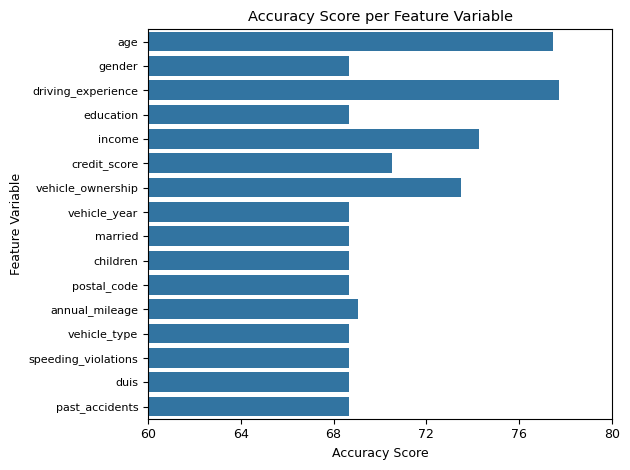

In [253]:
#Want to visualize the accuracy scores per feature

#convert the dictionary to a dataframe
acc_scores_df = pd.DataFrame([acc_scores]).T.reset_index().rename(columns={'index':'Feature Variable', 0:'Accuracy Score'})
#change the 'acc. score' column to a percentage
acc_scores_df['Accuracy Score (%)'] = acc_scores_df['Accuracy Score']*100

#plot the data
ax1 = sns.barplot(data=acc_scores_df.sort_values('Accuracy Score (%)', ascending=False), x='Accuracy Score (%)', 
                  y='Feature Variable', color=sns.color_palette()[0])

#edit plot details
plt.title('Accuracy Score per Feature Variable', fontsize=10.5)
plt.xlim(60,80)
plt.xticks(ticks=range(60,81,4), fontsize=9)
plt.xlabel('Accuracy Score', fontsize=9)
plt.yticks(fontsize=8)
plt.ylabel('Feature Variable', fontsize=9)
plt.tight_layout();

The figure above illustrates the accuracy score of each feature variable in predicting 10,000 "outcome" values. The lowest accuracy score was about 68.7%, which ten different feature variables had. The variables with the highest accuracy scores were "age" & "driving_experience" with scores of 77.5% & 77.7% respectively.

In [263]:
#assign the specified variables
best_feature_df = acc_scores_df.sort_values('Accuracy Score', ascending=False).reset_index(drop=True).head(1).drop(
    columns=['Accuracy Score (%)']).rename(columns={'Feature Variable':'best_feature', 'Accuracy Score':'best_accuracy'})

display(best_feature_df)

,best_feature,best_accuracy
0,driving_experience,0.7771
